In [28]:
# importacion de las librerias pandas para utilizar tablas y base de datso,
# numpy para trabar arreglos y operaciones, matplotlib se utiliza para crear graficas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
#cargar un dataset de cancer de maam incluido en sklearn
from sklearn.datasets import load_breast_cancer

In [30]:
#dividir los datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

In [31]:
#se utiliza para que la escala de datos sea iguales
from sklearn.preprocessing import StandardScaler

In [32]:
#se importa algoritmo de regresión
from sklearn.linear_model import LogisticRegression

In [33]:
#importa metricas para evaluar el modelo
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [34]:
#guardar y cargar el modelo
import joblib
#importa librerias weights y biases
import wandb
#interactuar con el sistema operativo

In [35]:
#inicializa el (MONITOREO Y LOGGING) definiendo el nombre, tipo de modelo, tamaña de prueba y el random state
wandb.init(
    project="data_journey_ml",
    name="clasificacion_cancer",
    config={
        "modelo": "LogisticRegression",
        "test_size": 0.2,
        "random_state": 42
    }
)

#guarada la configuraacion
config = wandb.config

In [36]:
#carga del dataset
data = load_breast_cancer()
#convierte los datos en tabla de dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)
#agrega al modelo las variable objetivo 0 y 1 replresnatan las clases
df["target"] = data.target


In [37]:
#mostra las primeras 5 filas del dataset
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  


**Manipualción de los datos**

In [38]:
# Variables X e y
X = df.drop("target", axis=1)
y = df["target"]

# División de datos para datos de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config.test_size,
    random_state=config.random_state
)

# Escalamiento
# se crea un objeto escalador para que aprenda el comportamiento de los datos
#trasnforma los datos en datos de prueba y entrenamiento
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
#entrena el modelo con 1000 interacciones y definiendo los datos de entrada y salida
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [40]:
#el modelo realiza predicciones utlizando los datos de prueba
y_pred = modelo.predict(X_test)

In [41]:
#se defiene las metricas con la cantidad de predicciones
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1-score: 0.9790209790209791


In [42]:
#genera la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(cm)


Matriz de confusión:
[[41  2]
 [ 1 70]]


In [43]:
#guarda automaticamente las matrices en la plataforma
wandb.log({
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
})


In [44]:
#gurda el modelo en un archivo .pkl
joblib.dump(modelo, "modelo_cancer.pkl")

print("\nModelo guardado correctamente.")

# Guardar archivo en W&B crea un artefacto en W&B.
# artifact:
# Permite almacenar archivos del experimento.
artifact = wandb.Artifact(
    "modelo_ml",
    type="model"
)
# Agrega el archivo del modelo.
artifact.add_file("modelo_cancer.pkl")
# Guarda el archivo en W&B.
wandb.log_artifact(artifact)


Modelo guardado correctamente.


<Artifact modelo_ml>

In [45]:
# Finaliza el monitoreo del experimento
wandb.finish()

accuracy,▁
f1_score,▁
precision,▁
recall,▁
accuracy,0.97368
f1_score,0.97902
precision,0.97222
recall,0.98592


In [46]:
#carga el modelo y realiza las predicciones
modelo_cargado = joblib.load("modelo_cancer.pkl")

# Tomar un ejemplo
ejemplo = X_test[0].reshape(1, -1)

prediccion = modelo_cargado.predict(ejemplo)

print("\nPredicción del modelo cargado:")
print(prediccion)


Predicción del modelo cargado:
[1]


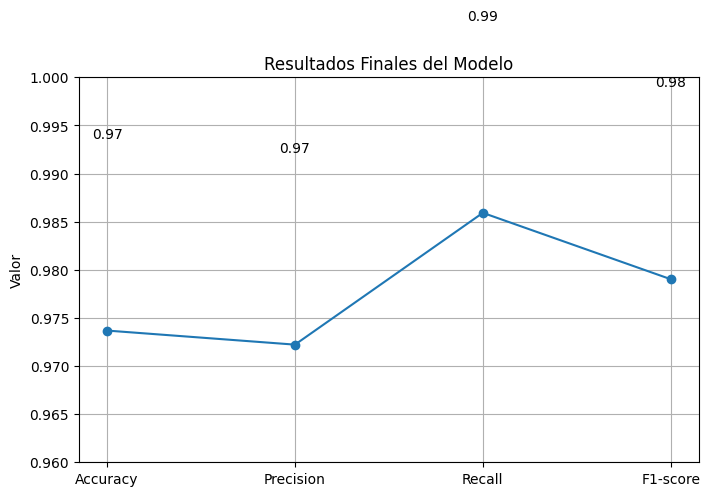

In [53]:
# Nombres de las métricas
metricas = ["Accuracy", "Precision", "Recall", "F1-score"]

# Valores de las métricas
valores = [accuracy, precision, recall, f1]

# Crear figura
plt.figure(figsize=(8,5))

# Crear gráfico de líneas
plt.plot(metricas, valores, marker='o')

# Título
plt.title("Resultados Finales del Modelo")

# Nombre eje Y
plt.ylabel("Valor")

# Límite del eje Y
plt.ylim(0.96, 1)

# Mostrar valores en cada punto
for i, valor in enumerate(valores):
    plt.text(i, valor + 0.02, f"{valor:.2f}", ha='center')

# Mostrar cuadrícula
plt.grid(True)

# Mostrar gráfico
plt.show()